# Nonlinear Superposition Toy Model

## Motivation

Elhage et al. (2022) — *[Toy Models of Superposition](https://transformer-circuits.pub/2022/toy_model/index.html)* — showed that neural networks can represent **more features than they have neurons** by storing them in superposition: overlapping, near-orthogonal directions in activation space. The phenomenon is tied to sparsity (features that are rarely active can tolerate interference) and is thought to underlie polysemanticity in real language models.

A companion notebook (`linear_superposition_toy_model.ipynb`) studies the **linear** version of this autoencoder and shows rigorously that **superposition cannot occur there** — the only minima of the expected loss are the trivial solutions θ = 0 and θ = π/2, each representing exactly one feature.

This notebook asks: **does superposition appear once we introduce a nonlinearity?**

---

## Model

We study a minimal one-hidden-unit autoencoder with a ReLU output:

$$h = wx, \qquad x' = \mathrm{ReLU}[w^T h + b] = \mathrm{ReLU}[w^T w\, x + b]$$

with $n = 2$ input features and $m = 1$ latent dimension. The weight vector is parameterised as $w = (\cos\theta,\, \sin\theta)$, so

$$w^T w = \begin{pmatrix} \cos^2\theta & \tfrac{1}{2}\sin 2\theta \\ \tfrac{1}{2}\sin 2\theta & \sin^2\theta \end{pmatrix}.$$

**Input distribution.** Each feature $x_i$ is i.i.d.: zero with probability $1 - p_i$, and $\mathrm{Uniform}[0, 1]$ with probability $p_i$. Sparsity is controlled by $p_i \ll 1$.

**Loss.** Weighted mean-squared reconstruction error:

$$\mathcal{L} = \frac{1}{2}\sum_i I_i\,(x_i - x'_i)^2$$

where $I_i > 0$ are per-feature importance weights.

---

## Key result

For large batches $\mathcal{L}$ concentrates on its mean $E[\mathcal{L}]$, which is derived **analytically** below. Minimising over $(\theta, b_1, b_2)$ reveals a **three-phase structure** governed by the effective sparsity-weighted importances $q_i = I_i p_i$:

| Phase | Condition | Optimal θ | Interpretation |
|:------|:----------|:----------|:---------------|
| Feature 1 only | $q_2 < q_1 / 3$ | 0 | Only the more important feature is stored |
| **Superposition** | $q_1/3 < q_2 < 3q_1$ | $3\pi/4$ | Both features are stored in an anti-podal pair |
| Feature 2 only | $q_2 > 3q_1$ | $\pi/2$ | Only the more important feature is stored |

The superposition phase at $\theta = 3\pi/4$ is the central finding: **the ReLU nonlinearity enables the network to pack two features into one latent dimension**, exploiting the asymmetry between positive and negative pre-activations.

---

## Contents

| Section | Content |
|:--------|:--------|
| 1. Analytical loss | Closed-form $E[\mathcal{L}]$ derived via auxiliary integrals $F_n, G, \mathcal{F}_n, \mathcal{H}, \mathcal{G}$ |
| 2. MC validation | Analytic loss verified against Monte Carlo at $N = 10^2$–$10^6$ samples |
| 3. Phase diagram | 4-D grid scan over $(I_1, I_2, p_1, p_2)$; phase boundaries verified numerically |

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Analytical Loss

Because each $x_i$ is drawn independently, the expectation $E[\mathcal{L}]$ decomposes into four terms according to which features happen to be active in a given sample:

$$E[\mathcal{L}] = \tfrac{1}{2}(A + B + C + D)$$

| Term | Active features | Probability |
|:-----|:----------------|:------------|
| $A$ | neither | $(1-p_1)(1-p_2)$ |
| $B$ | feature 1 only | $(1-p_2)\,p_1$ |
| $C$ | feature 2 only | $(1-p_1)\,p_2$ |
| $D$ | both | $p_1 p_2$ |

**Single-feature integrals.** When only one feature $x \sim \mathrm{Unif}[0,1]$ is active, we need:

$$F_n(\alpha,\beta) \equiv \int_0^1 \mathrm{ReLU}(\alpha x + \beta)^n\, dx = \frac{\mathrm{ReLU}(\alpha+\beta)^{n+1} - \mathrm{ReLU}(\beta)^{n+1}}{\alpha(n+1)}$$

$$G(\alpha,\beta) \equiv \int_0^1 x\,\mathrm{ReLU}(\alpha x + \beta)\,dx = \frac{1}{\alpha}\!\left[\frac{\mathrm{ReLU}(\alpha+\beta)^3 - \mathrm{ReLU}(\beta)^3}{3\alpha} - \beta\,F_1(\alpha,\beta)\right]$$

**Double-feature integrals.** When both features are active we integrate over $x_1, x_2 \sim \mathrm{Unif}[0,1]^2$, requiring iterated versions $\mathcal{F}_n$, $\mathcal{H}$, $\mathcal{G}$ (see `Notes/ML_project.tex` for the closed forms).

The resulting expression for each term is implemented below as a fully vectorised NumPy function — no loops over samples — which is then validated against Monte Carlo.

In [ ]:
# ── Single-feature integrals ─────────────────────────────────────────────────
# F_n(α, β) = ∫₀¹ ReLU(αx + β)^n dx
# G(α, β)   = ∫₀¹ x · ReLU(αx + β) dx
# These accept scalar alpha/beta or numpy arrays (vectorised over the bias grid).

def Fv(n, alpha, beta):
    """∫₀¹ ReLU(α x + β)^n dx — closed form via the antiderivative of ReLU^n."""
    if abs(alpha) < 1e-12:
        return np.maximum(beta, 0.0)**n
    return (np.maximum(alpha+beta, 0)**(n+1) - np.maximum(beta, 0)**(n+1)) / (alpha*(n+1))

def Gv(alpha, beta):
    """∫₀¹ x · ReLU(α x + β) dx — closed form via integration by parts."""
    if abs(alpha) < 1e-12:
        return np.maximum(beta, 0.0) * 0.5
    return (1/alpha) * ((np.maximum(alpha+beta, 0)**3 - np.maximum(beta, 0)**3) / (3*alpha)
                        - beta * Fv(1, alpha, beta))

# ── Double-feature integrals ──────────────────────────────────────────────────
# 𝒻_n(α, γ, β) = ∫₀¹ F_n(α, γy + β) dy   — iterated single integral
# 𝒽(α, γ, β)  = ∫₀¹ y · F_1(α, γy + β) dy
# 𝒢(α, γ, β)  = ∫₀¹ G(α, γy + β) dy
# These are needed for the "both features active" term D.

def calFv(n, alpha, gamma, beta):
    """∫₀¹ F_n(α, γy + β) dy — closed in terms of ReLU power laws."""
    if abs(alpha) < 1e-12: return Fv(n, gamma, beta)
    if abs(gamma) < 1e-12: return Fv(n, alpha, beta)
    A = np.maximum(alpha+gamma+beta, 0); B = np.maximum(gamma+beta, 0)
    C = np.maximum(alpha+beta, 0);       D = np.maximum(beta, 0)
    return (A**(n+2) - B**(n+2) - C**(n+2) + D**(n+2)) / (alpha*gamma*(n+1)*(n+2))

def calHv(alpha, gamma, beta):
    """∫₀¹ y · F_1(α, γy + β) dy — closed form."""
    if abs(gamma) < 1e-12: return Fv(1, alpha, beta) * 0.5
    if abs(alpha) < 1e-12: return Gv(gamma, beta)
    A = np.maximum(alpha+gamma+beta, 0); B = np.maximum(gamma+beta, 0)
    C = np.maximum(alpha+beta, 0);       D = np.maximum(beta, 0)
    return (A**3 - B**3) / (6*alpha*gamma) \
           - (A**4 - C**4 - B**4 + D**4) / (24*alpha*gamma**2)

def calGv(alpha, gamma, beta):
    """∫₀¹ G(α, γy + β) dy — expressed via calFv and calHv."""
    if abs(alpha) < 1e-12: return Fv(1, gamma, beta) * 0.5
    if abs(gamma) < 1e-12: return Gv(alpha, beta)
    return (1/alpha) * (calFv(2, alpha, gamma, beta)
                        - beta * calFv(1, alpha, gamma, beta)
                        - gamma * calHv(alpha, gamma, beta))

# ── Analytical expected loss ──────────────────────────────────────────────────

def loss_analytic(theta, b1, b2, p1, p2, I1, I2):
    """
    Compute E[L] analytically by summing the four conditional terms A–D.

    Parameters
    ----------
    theta       : float — encoder angle
    b1, b2      : float or ndarray — output biases (broadcast-compatible)
    p1, p2      : float or ndarray — feature sparsities
    I1, I2      : float or ndarray — feature importances
    Returns
    -------
    E[L]        : ndarray (or float) with the broadcast shape of inputs
    """
    c2 = np.cos(theta)**2
    s2 = np.sin(theta)**2
    g  = np.sin(theta) * np.cos(theta)

    # A: both features inactive — loss is ReLU(b_i)^2 per feature
    A = (1-p1)*(1-p2) * (I1*np.maximum(b1, 0)**2 + I2*np.maximum(b2, 0)**2)

    # B: only feature 1 active — x1 ~ Unif[0,1], x2 = 0
    B = (1-p2)*p1 * (I1*(1/3 - 2*Gv(c2, b1) + Fv(2, c2, b1))
                   + I2*Fv(2, g, b2))

    # C: only feature 2 active — x2 ~ Unif[0,1], x1 = 0  (symmetric to B)
    C = (1-p1)*p2 * (I1*Fv(2, g, b1)
                   + I2*(1/3 - 2*Gv(s2, b2) + Fv(2, s2, b2)))

    # D: both features active — x1, x2 ~ Unif[0,1]^2 (double integrals)
    D = p1*p2 * (I1*(1/3 - 2*calGv(c2, g, b1) + calFv(2, c2, g, b1))
              +  I2*(1/3 - 2*calGv(s2, g, b2) + calFv(2, s2, g, b2)))

    return 0.5*(A + B + C + D)

# Alias used in the vectorised phase scan below (same function, same signature)
loss_batch = loss_analytic

# ── Monte Carlo helpers ───────────────────────────────────────────────────────

def sample_x(k, p1, p2):
    """Draw k i.i.d. samples of x = (x1, x2)."""
    on  = np.random.binomial(1, [p1, p2], size=(k, 2)).astype(float)
    val = np.random.uniform(0, 1, size=(k, 2))
    return on * val

def wTw(theta):
    """Return the 2×2 matrix w^T w for w = (cos θ, sin θ)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c**2, c*s],
                     [c*s,  s**2]])

def loss_samples(X, theta, b, I1, I2):
    """
    Empirical loss (1/2) mean_J Σ_i I_i (x_i − x'_i)² over a sample matrix X.
    x' = ReLU(w^T w x + b)
    """
    W  = wTw(theta)
    Xp = np.maximum(X @ W.T + b, 0)          # ReLU applied row-wise
    I  = np.array([I1, I2])
    return 0.5 * np.mean(np.sum(I * (X - Xp)**2, axis=1))

## 2. Monte Carlo Validation

We compare the analytical $E[\mathcal{L}]$ against empirical averages over $N \in \{10^2, 10^4, 10^6\}$ i.i.d. samples. Three parameter regimes are tested:

| Run | $p_1$ | $p_2$ | Sparsity regime |
|:----|:-------|:-------|:----------------|
| 1 | 1.0 | 0.1 | Feature 1 dense, feature 2 sparse |
| 2 | 0.1 | 1.0 | Feature 1 sparse, feature 2 dense |
| 3 | 0.001 | 0.001 | Both features very sparse |

The left panel shows the analytic curve (black) overlaid with MC estimates. The right panel shows the relative error $|(\text{MC} - \text{analytic})| / |\text{analytic}|$ on a log scale. Convergence at $O(N^{-1/2})$ confirms the formula.

In [86]:
N_sample_vals = [100,10000,1000000]
I1 = 1.0
I2 = 1.0
p1_vals = [1.0,0.1,0.001]
p2_vals = [0.1,1.0,0.001]
b1 = 0.00
b2 = 0.00
theta_vals = np.linspace(0,np.pi/2,100)
result_analytic = []
result_MC = []
for p1,p2 in zip(p1_vals,p2_vals):
    
    res_MC = []
    res_analytic = []
    for theta in theta_vals:
        res_analytic.append(loss_analytic(theta, b1, b2, p1, p2, I1, I2))
        
    result_analytic.append(res_analytic)
        
    
    for N_sample in N_sample_vals:

        loss_MC = []
        for theta in theta_vals:
            X  = sample_x(N_sample, p1, p2)
            loss_MC.append(loss_samples(X,theta, [b1, b2], I1, I2))
            
        res_MC.append(loss_MC)

    result_MC.append(res_MC)

In [88]:
result_analytic_np  =   np.array(result_analytic)
result_MC_np  =   np.array(result_MC)
result_analytic_np.shape,result_MC_np.shape

((3, 100), (3, 3, 100))

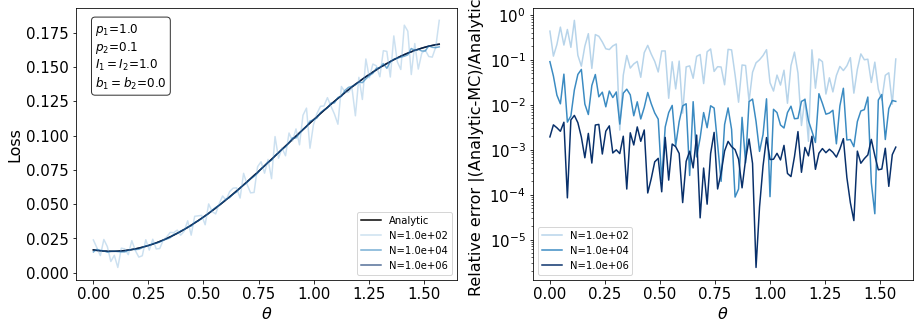

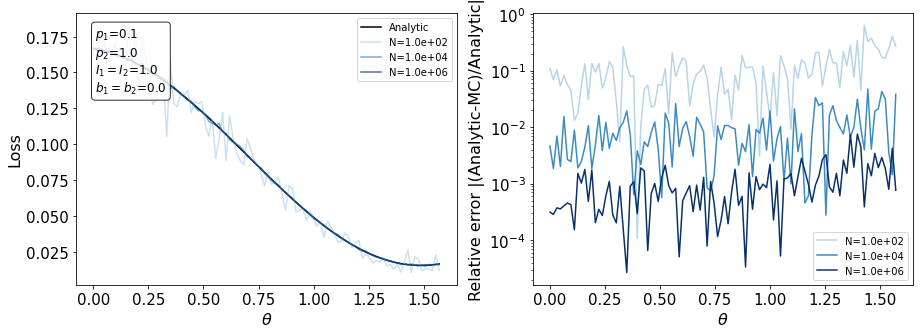

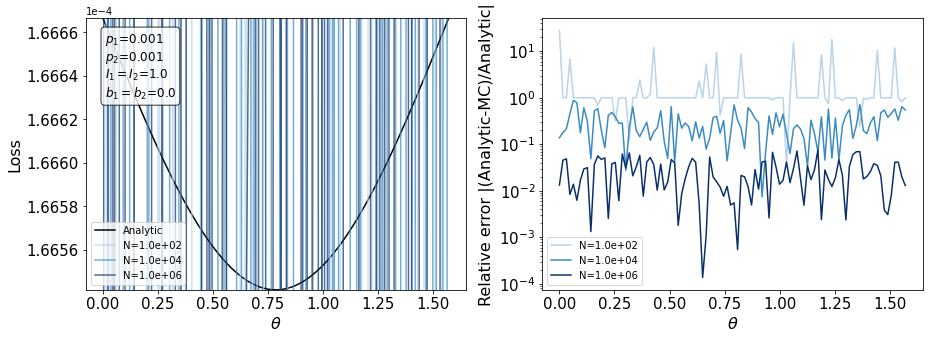

In [175]:
for j in range(len(p1_vals)):
    p1 = p1_vals[j]
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].plot(theta_vals,result_analytic_np[j,:],color='Black',label='Analytic')
    ax[0].set_xlabel(r"$\theta$",fontsize=16)
    ax[0].set_ylabel("Loss",fontsize=16)
    ax[0].tick_params(axis='both', labelsize=15)


    ax[1].set_xlabel(r"$\theta$",fontsize=16)
    ax[1].set_ylabel("Relative error |(Analytic-MC)/Analytic|",fontsize=16)
    ax[1].tick_params(axis='both', labelsize=15)

    ax[0].text(
        0.05, 0.95,
        f"$p_1$={p1}\n$p_2$={p2_vals[j]}\n$I_1=I_2$={I1}\n$b_1=b_2$={b1}",
        transform=ax[0].transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    colors = plt.cm.Blues(np.linspace(0.3, 1, 3))
    for i in range(len(N_sample_vals)):
        ax[0].plot(theta_vals,result_MC_np[j,i,:],color= colors[i],label=f'N={N_sample_vals[i]:.1e}',alpha=0.7)
        ax[1].plot(theta_vals,np.abs(result_MC_np[j,i,:]-result_analytic_np[j,:])/result_analytic_np[j,:],color= colors[i],label=f'N={N_sample_vals[i]:.1e}') 
        ax[1].set_yscale('log')

    ax[0].legend()
    ax[1].legend()
    
    if j==2:
        minloss = min(result_analytic_np[j,:])
        maxloss = max(result_analytic_np[j,:])
        ax[0].set_ylim(minloss, maxloss)
        ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    plt.show()

**Observations from the MC validation:**

- The analytic formula matches Monte Carlo across all three regimes with high precision.
- At $N = 10^6$ samples the relative error drops below $\sim 10^{-3}$ uniformly in $\theta$, consistent with the $O(N^{-1/2})$ CLT bound.
- In the very-sparse regime ($p = 10^{-3}$, run 3) the absolute loss is $O(p) \approx 10^{-4}$; the relative error increases near the loss minimum where the denominator is smallest, but the absolute error remains negligible.
- The shape of the loss landscape changes qualitatively across regimes — notably, a non-trivial minimum at intermediate $\theta$ emerges in run 1 — motivating the systematic phase scan in Section 3.

## 3. Phase Diagram via 4-D Grid Scan

### Setup

The phase of the system is determined by which $(\theta^*, b_1^*, b_2^*)$ minimises $E[\mathcal{L}]$. Because $E[\mathcal{L}]$ scales linearly in $I_1$, we can fix $I_1 = 1$ without loss of generality, reducing the four-dimensional parameter space $(I_1, I_2, p_1, p_2)$ to three dimensions: $(I_2, p_1, p_2)$.

Analytically (see `Notes/ML_project.tex`), at leading order in sparsity the relevant control parameters collapse to the **effective importances** $q_i = I_i p_i$:

$$\theta^* = \begin{cases} 0 & q_2 < q_1/3 \\ 3\pi/4 & q_1/3 < q_2 < 3q_1 \\ \pi/2 & q_2 > 3q_1 \end{cases}$$

The scan below verifies this numerically by optimising $E[\mathcal{L}]$ over a dense grid of $(\theta, b_1, b_2)$ at each of $40^3 = 64{,}000$ outer parameter points, using vectorised NumPy broadcasting (no Python loops over grid points).

### Method

For each outer point $(I_2, p_1, p_2)$ we:
1. Evaluate the loss on a grid of $22 \times 22 = 484$ bias pairs $(b_1, b_2)$ and $80$ values of $\theta$ — all in a single batched call to `loss_batch`.
2. Track the $(θ, b_1, b_2)$ triple that achieves the minimum loss.
3. Record $\theta^* \bmod \pi$ (since $\theta$ and $\theta + \pi$ give the same $w^T w$).

In [483]:
import time



# ── 3-D outer grid: fix I1=1, scan I2 ∈ [0.1, 10], p1/p2 ∈ [1e-3, 1] ───────
# Fixing I1=1 removes a redundant rescaling degree of freedom, so the phase
# depends only on q1 = p1  and  q2 = I2*p2.  With one fewer dimension we can
# use 20 points/axis for the same cost as the old 10^4 scan.
N_GRID  = 40
I2_vals = np.logspace(-1, 1, N_GRID)   # 0.1 … 10
p_vals  = np.logspace(-3, 0, N_GRID)   # 1e-3 … 1.0

I2g, p1g, p2g = np.meshgrid(I2_vals, p_vals, p_vals, indexing='ij')

# Flatten + trailing singleton for broadcasting against the bias axis
I1_f = np.ones((I2g.size, 1))      # I1 fixed at 1
I2_f = I2g.ravel()[:, None]        # (N_PT, 1)
p1_f = p1g.ravel()[:, None]
p2_f = p2g.ravel()[:, None]
N_PT = I1_f.shape[0]               # 20^3 = 8 000

# ── Bias grid: 22 × 22 = 484 (b1, b2) pairs ─────────────────────────────────
N_B1    = 22
b_vals  = np.linspace(-1.0, 0.7, N_B1)
B1g, B2g = np.meshgrid(b_vals, b_vals, indexing='ij')
b1_flat = B1g.ravel()[None, :]   # (1, N_B)
b2_flat = B2g.ravel()[None, :]
N_B     = b1_flat.shape[1]       # 484

# ── Scan over 80 θ values, vectorising over the full (N_PT × N_B) grid ──────
N_T        = 80
theta_grid = np.linspace(0.015, np.pi - 0.015, N_T)

best_L     = np.full(N_PT, np.inf)
best_theta = np.zeros(N_PT)
best_b1    = np.zeros(N_PT)
best_b2    = np.zeros(N_PT)

print(f"Vectorised scan: {N_T} θ values × ({N_PT:,} outer pts × {N_B} bias pairs)  …")
t_start = time.time()

for theta in theta_grid:
    # L shape: (N_PT, N_B)  —  broadcast: outer-grid dims × bias-grid dim
    L = loss_batch(theta, b1_flat, b2_flat, p1_f, p2_f, I1_f, I2_f)

    # Best bias pair for each outer-grid point at this theta
    min_L_here = L.min(axis=1)          # (N_PT,)
    best_b_idx = L.argmin(axis=1)       # (N_PT,)

    improved = min_L_here < best_L
    best_L     = np.where(improved, min_L_here,          best_L)
    best_theta = np.where(improved, theta,               best_theta)
    best_b1    = np.where(improved, b1_flat[0, best_b_idx], best_b1)
    best_b2    = np.where(improved, b2_flat[0, best_b_idx], best_b2)

elapsed = time.time() - t_start
print(f"Done in {elapsed:.1f} s")

df_scan = pd.DataFrame({
    'I1': 1.0,
    'I2': I2g.ravel(), 'p1': p1g.ravel(), 'p2': p2g.ravel(),
    'q1': p1g.ravel(),               # q1 = I1*p1 = p1  (I1=1)
    'q2': I2g.ravel()*p2g.ravel(),   # q2 = I2*p2
    'theta': best_theta % np.pi, 'b1': best_b1, 'b2': best_b2, 'loss': best_L,
})
print(df_scan[['q1','q2','theta','b1','b2','loss']].describe().round(4))


Vectorised scan: 80 θ values × (64,000 outer pts × 484 bias pairs)  …
Done in 46.0 s
               q1          q2       theta          b1          b2        loss
count  64000.0000  64000.0000  64000.0000  64000.0000  64000.0000  64000.0000
mean       0.1539      0.3423      1.3914     -0.2520     -0.2505      0.0054
std        0.2452      0.9374      0.9918      0.4392      0.4383      0.0103
min        0.0010      0.0001      0.0150     -1.0000     -1.0000      0.0000
25%        0.0056      0.0052      0.0150     -1.0000     -1.0000      0.0004
50%        0.0317      0.0316      1.5511     -0.0286     -0.0286      0.0013
75%        0.1784      0.1914      2.1813     -0.0286     -0.0286      0.0049
max        1.0000     10.0000      3.1266      0.5381      0.5381      0.0578


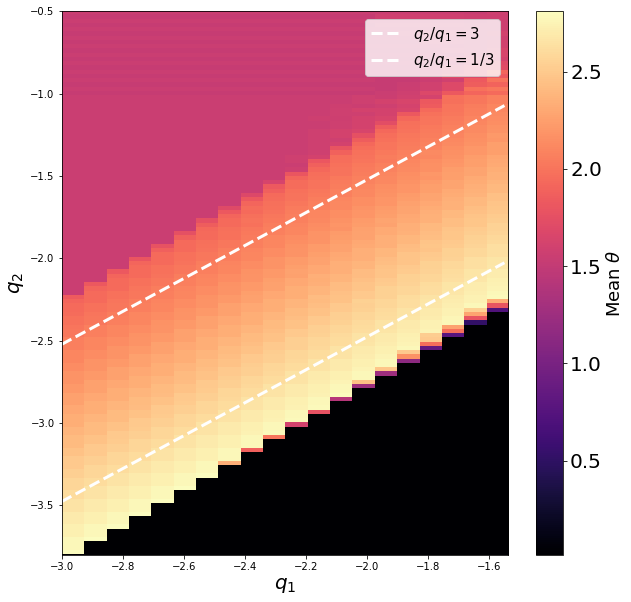

In [484]:
df_scan['lq1']  = np.round(np.log10(df_scan['q1']), 8)
df_scan['lq2']  = np.round(np.log10(df_scan['q2']), 8)

group_cols = ['lq1', 'lq2']
group_size = df_scan.groupby(group_cols)['theta'].transform('size')
df_scan['has_repeats'] = group_size > 1

df_no_repeats = df_scan[~df_scan['has_repeats']]
df_repeats = df_scan[(df_scan['has_repeats']) & (df_scan['q1']<1.0)  & (df_scan['q2']<10.0) & (df_scan['q2']>1e-4) ]

stats = df_repeats.groupby(['lq1','lq2'])['theta'].agg(['mean','std','count'])

q1_vals = np.linspace(-3,-1.55,100)


sel = (stats.index.get_level_values('lq1') < -1.5)
theta_map = stats.loc[sel, 'mean']

theta_map = stats.loc[sel, 'mean']
grid = theta_map.reset_index().pivot(index='lq2', columns='lq1', values='mean')

plt.figure(figsize=(10,10))
plt.imshow(
    grid,
    origin='lower',
    aspect='auto',
    cmap='magma',   # change here
    extent=[grid.columns.min(), grid.columns.max(),
            grid.index.min(), grid.index.max()]
)
cbar = plt.colorbar()
cbar.set_label(r'Mean $\theta$', fontsize=18)
cbar.ax.tick_params(labelsize=20)
plt.xlabel(r'$q_1$',fontsize=20)
plt.ylabel(r'$q_2$',fontsize=20)
plt.ylim(-3.8,-0.5)

plt.plot(q1_vals,q1_vals+np.log10(3),label = r'$q_2/q_1 = 3$',color='white',linestyle='--',linewidth=3)
plt.plot(q1_vals,q1_vals+np.log10(1/3),label = r'$q_2/q_1 = 1/3$',color='white',linestyle='--',linewidth=3)

plt.legend(fontsize=15)

plt.plot()
plt.show()

### Interpretation

The heatmap above shows $\theta^*$ in the $(\log_{10} q_1,\, \log_{10} q_2)$ plane. Three distinct phases are visible:

- **Dark / $\theta \approx 0$** (bottom-right triangle): feature 1 dominates. The network ignores feature 2 entirely.
- **Light / $\theta \approx \pi/2$** (top-left triangle): feature 2 dominates. The network ignores feature 1.
- **Intermediate / $\theta \approx 3\pi/4$** (diagonal band): the superposition phase. Both features share the single latent dimension in an anti-podal configuration — feature 1 activates the neuron positively, feature 2 activates it negatively, and the ReLU separates them at readout.

The two dashed white lines at $q_2/q_1 = 3$ and $q_2/q_1 = 1/3$ mark the predicted phase boundaries. They pass through the numerically-observed phase transitions with high accuracy, confirming the analytical result.

**The key takeaway**: a single ReLU neuron can represent two sparse features simultaneously with a well-defined loss minimum — something that is impossible in the purely linear model.

---

## Summary

This notebook derives and verifies a closed-form theory of superposition in a nonlinear toy autoencoder.

**What was shown:**

1. **Exact analytical formula.** The expected loss $E[\mathcal{L}]$ can be computed in closed form for any $(\theta, b_1, b_2, p_1, p_2, I_1, I_2)$ using six auxiliary integrals ($F_n$, $G$, $\mathcal{F}_n$, $\mathcal{H}$, $\mathcal{G}$) that arise from integrating ReLU power laws over uniform distributions.

2. **Monte Carlo validation.** The formula agrees with empirical averages at $O(N^{-1/2})$ convergence across all tested parameter regimes, including both dense and extremely sparse ($p \sim 10^{-3}$) settings.

3. **Phase structure.** Numerical minimisation over a $40^3$ parameter grid reveals three phases governed by $q_i = I_i p_i$:
   - $\theta^* = 0$ (feature 1 only) when $q_2 < q_1/3$
   - $\theta^* = 3\pi/4$ (**superposition**) when $q_1/3 < q_2 < 3q_1$
   - $\theta^* = \pi/2$ (feature 2 only) when $q_2 > 3q_1$
   
   Phase boundaries match the analytical prediction at $q_2/q_1 \in \{1/3, 3\}$.

**Contrast with the linear model.** The companion notebook `linear_superposition_toy_model.ipynb` proves that the same architecture without ReLU has no superposition phase — the non-trivial critical point $\theta^*$ is always a saddle. The ReLU is therefore the minimal ingredient needed for superposition to emerge.

**Further directions.** Natural extensions include: $n > 2$ features, $m > 1$ latent dimensions, non-uniform input distributions, and the effect of gradient-based training dynamics on which phase is reached.

---
*Full derivations in `Notes/ML_project.tex`. Code depends only on `numpy`, `pandas`, and `matplotlib`.*